In [12]:
# 1. Import Libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [13]:
# 2. Load Dataset
df = pd.read_csv("C:/Users/Acer/Downloads/q2_customers.csv")

In [14]:
# Display first rows
df.head()

# Separate features (no target in clustering)
X = df.copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature scaling was applied using StandardScaler to normalize all variables. This step is essential before applying K-Means because the algorithm is distance-based and uses Euclidean distance to form clusters.
If features are on different scales (e.g., annual spend vs number of visits), variables with larger values will dominate the clustering process, leading to biased results. Scaling ensures that all features contribute equally.

C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

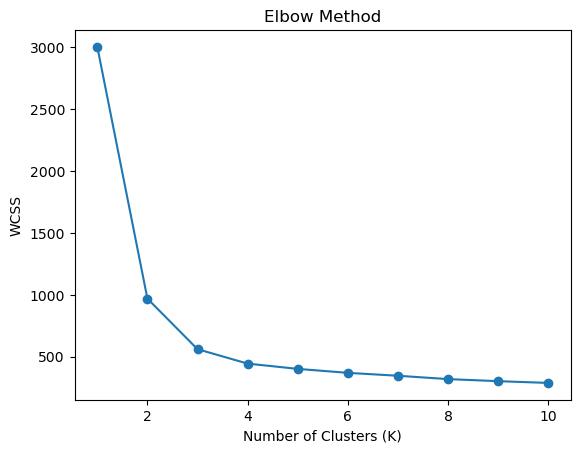

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

The elbow method helps determine the optimal number of clusters by plotting WCSS against the number of clusters.
The point where the curve starts to flatten (forming an "elbow") indicates the optimal K. This is because adding more clusters beyond this point results in diminishing returns in reducing WCSS.

In [16]:
# Choose K (example: 3 — change based on your graph)
k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
df['cluster'] = clusters

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

print("Cluster Centroids:\n")
print(centroids)

Cluster Centroids:

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


### Cluster 0
Cluster 0 represents young customers (average age ≈ 25) who have moderate to high annual spending (~14,847) and very frequent visits (~14 visits/month). However, their basket size is relatively low, and they purchase from fewer categories (~2). This suggests frequent but low-volume buying behavior.

### Cluster 1
Cluster 1 consists of older customers (average age ≈ 57) with very high annual spending (~89,413) but low visit frequency (~2.5 visits/month). Their basket size is very high (~5,530), and they purchase from many categories (~7.5). These are high-value but infrequent buyers.

### Cluster 2
Cluster 2 represents middle-aged customers (average age ≈ 40) with moderate spending (~43,340) and moderate visit frequency (~8 visits/month). Their basket size and category diversity are balanced, indicating regular and stable customers.

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

print("\nFeature Loadings:\n")
print(loadings)

Explained Variance Ratio: [0.83560354 0.05568764]

Feature Loadings:

          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


PCA reduces the dataset into two principal components while preserving maximum variance.
PC1 captures the most important variation in the data, primarily influenced by features with high loadings (e.g., annual spend and basket size).
PC2 captures the second most important variation, often representing behavioral differences such as visit frequency or product diversity

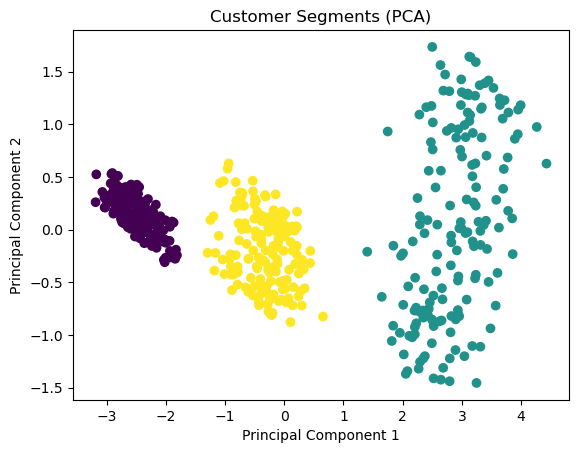

In [18]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.title('Customer Segments (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()